# Principle Component Analysis

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

## Importing Dataset

In [4]:
df = pd.read_csv("../Datasets/sonar.csv")

In [5]:
df.head()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [6]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.4328  207 n

In [7]:
display(df.describe())

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,...,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.029208,0.038443,0.043837,0.054053,0.075105,0.104599,0.121591,0.134677,0.177361,0.208245,...,0.016034,0.013472,0.010729,0.010917,0.009300,0.008181,0.007771,0.007947,0.007936,0.006523
std,0.023038,0.033040,0.038521,0.046583,0.055669,0.059247,0.061897,0.085340,0.118311,0.134741,...,0.012027,0.009628,0.007071,0.007310,0.007103,0.005719,0.005756,0.006485,0.006196,0.005038
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013300,0.016400,0.018900,0.024450,0.037700,0.066950,0.080600,0.080350,0.096750,0.111150,...,0.008350,0.007350,0.005050,0.005350,0.004100,0.004400,0.003700,0.003600,0.003650,0.003100
50%,0.022800,0.030800,0.034200,0.044100,0.062000,0.092100,0.105600,0.111900,0.152200,0.181000,...,0.013800,0.011500,0.009600,0.009300,0.007500,0.006800,0.005900,0.005800,0.006300,0.005300
75%,0.035800,0.048100,0.058200,0.065700,0.101050,0.134150,0.153050,0.169800,0.231500,0.269000,...,0.020700,0.016750,0.014900,0.014450,0.012100,0.010350,0.010350,0.010400,0.010350,0.008550
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


array([[<Axes: title={'center': '0.0200'}>,
        <Axes: title={'center': '0.0371'}>,
        <Axes: title={'center': '0.0428'}>,
        <Axes: title={'center': '0.0207'}>,
        <Axes: title={'center': '0.0954'}>,
        <Axes: title={'center': '0.0986'}>,
        <Axes: title={'center': '0.1539'}>,
        <Axes: title={'center': '0.1601'}>],
       [<Axes: title={'center': '0.3109'}>,
        <Axes: title={'center': '0.2111'}>,
        <Axes: title={'center': '0.1609'}>,
        <Axes: title={'center': '0.1582'}>,
        <Axes: title={'center': '0.2238'}>,
        <Axes: title={'center': '0.0645'}>,
        <Axes: title={'center': '0.0660'}>,
        <Axes: title={'center': '0.2273'}>],
       [<Axes: title={'center': '0.3100'}>,
        <Axes: title={'center': '0.2999'}>,
        <Axes: title={'center': '0.5078'}>,
        <Axes: title={'center': '0.4797'}>,
        <Axes: title={'center': '0.5783'}>,
        <Axes: title={'center': '0.5071'}>,
        <Axes: title={'center'

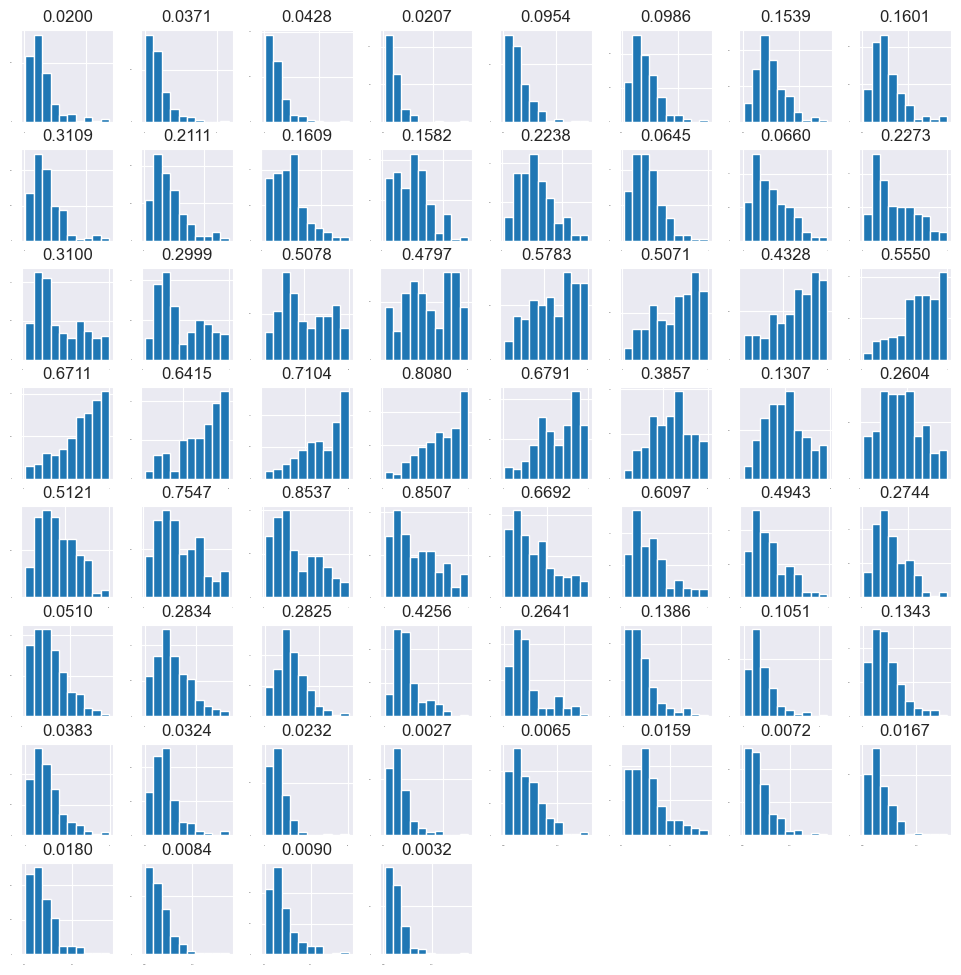

In [8]:
df.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(12,12))

## Defining Target and Independent Variables

<llm-snippet-file>/Users/anshumaansoni/PycharmProjects/Machine-Learning/Unsupervised-Learning/PCA_2.ipynb</llm-snippet-file>


In [ ]:
X = df.select_dtypes(include=['float64', 'int64'])

Y = df.select_dtypes(include=['object'])
if Y.empty:
    pass

X = df.select_dtypes(include=['float64', 'int64'])


## Applying Standard Scaler and Finding Covariance Matrix

In [11]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [12]:
cov_mat = np.cov(X_scaled.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)
print("Eigenvalues:\n {} \n".format(eigen_values))
print("Eigenvectors:\n {} \n".format(eigen_vectors))
print("Covariance Matrix:\n {} \n".format(cov_mat))

Eigenvalues:
 [1.22932648e+01 1.14194939e+01 5.16104108e+00 3.42974586e+00
 3.02250359e+00 2.44521871e+00 1.97316940e+00 1.83001690e+00
 1.55075630e+00 1.50135268e+00 1.25388613e+00 1.14882924e+00
 1.05754225e+00 9.29285286e-01 8.63235988e-01 8.14720475e-01
 7.41595261e-01 6.72584750e-01 6.22703242e-01 5.90603617e-01
 5.61767078e-01 5.31916811e-01 5.07277178e-01 4.67454383e-01
 4.36724677e-01 4.21149647e-01 3.65237972e-01 3.21301422e-01
 3.16815912e-01 2.96695578e-01 2.87763776e-01 2.63432373e-01
 2.22372165e-01 1.97068263e-01 1.86861013e-01 1.83238945e-01
 1.73373485e-01 1.47479261e-01 1.32317440e-01 1.24437794e-01
 1.11652522e-01 9.56470242e-02 8.13529777e-02 7.52096327e-02
 6.13257834e-02 5.71805661e-02 5.43806410e-02 4.26604768e-02
 6.53197685e-03 1.12876032e-02 1.15846379e-02 3.37183987e-02
 3.15836988e-02 2.91005549e-02 2.69415734e-02 1.49736997e-02
 1.61794686e-02 1.93308108e-02 2.29247397e-02 2.14606784e-02] 

Eigenvectors:
 [[-0.13692131 -0.12150865 -0.01513301 ... -0.05358261

## Getting Eigen Values in Descending Order

In [13]:
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:,i]) for i in range(len(eigen_values))]
print("Eigen Values in descending order:")
eigen_pairs.sort(key=lambda x: x[0], reverse=True)
for eigen_value, eigen_vector in eigen_pairs:
    print(eigen_value)

Eigen Values in descending order:
12.293264782276143
11.419493948070098
5.161041078360682
3.4297458631407363
3.0225035900738875
2.445218713723225
1.973169403322368
1.8300169018136256
1.5507562954196195
1.5013526789914307
1.2538861349581245
1.1488292392533384
1.057542249607076
0.9292852863212718
0.8632359883698759
0.8147204747739745
0.7415952606730731
0.672584750487883
0.6227032421105465
0.5906036174372313
0.5617670775642657
0.5319168109697869
0.5072771784731037
0.46745438315585125
0.4367246772700679
0.4211496465905856
0.3652379719095386
0.32130142171521164
0.3168159115334159
0.2966955775441872
0.28776377579744294
0.26343237279940585
0.2223721651367337
0.19706826348614756
0.18686101321190252
0.1832389451966305
0.17337348483902415
0.14747926116492338
0.13231744009707666
0.1244377935553556
0.1116525219850184
0.09564702417864887
0.0813529776908149
0.07520963270998016
0.061325783425912925
0.0571805660736535
0.05438064101912046
0.042660476776775196
0.03371839865052705
0.031583698803133074
0.

## Performing PCA

In [14]:
pca = PCA()
pca = pca.fit(X_scaled)

In [15]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([2.03897950e-01, 1.89405455e-01, 8.56018085e-02, 5.68862840e-02,
       5.01317021e-02, 4.05567677e-02, 3.27272864e-02, 3.03529373e-02,
       2.57210787e-02, 2.49016628e-02, 2.07971452e-02, 1.90546557e-02,
       1.75405558e-02, 1.54132664e-02, 1.43177628e-02, 1.35130771e-02,
       1.23002112e-02, 1.11555925e-02, 1.03282502e-02, 9.79584100e-03,
       9.31755378e-03, 8.82245274e-03, 8.41377607e-03, 7.75326916e-03,
       7.24358160e-03, 6.98525179e-03, 6.05789229e-03, 5.32915402e-03,
       5.25475666e-03, 4.92103776e-03, 4.77289354e-03, 4.36932921e-03,
       3.68829839e-03, 3.26860405e-03, 3.09930505e-03, 3.03922888e-03,
       2.87559886e-03, 2.44611335e-03, 2.19463709e-03, 2.06394408e-03,
       1.85188563e-03, 1.58641602e-03, 1.34933280e-03, 1.24743835e-03,
       1.01715873e-03, 9.48405524e-04, 9.01965543e-04, 7.07573125e-04,
       5.59258464e-04, 5.23852009e-04, 4.82666208e-04, 4.46857015e-04,
       3.80233202e-04, 3.55950060e-04, 3.20623754e-04, 2.68355115e-04,
      

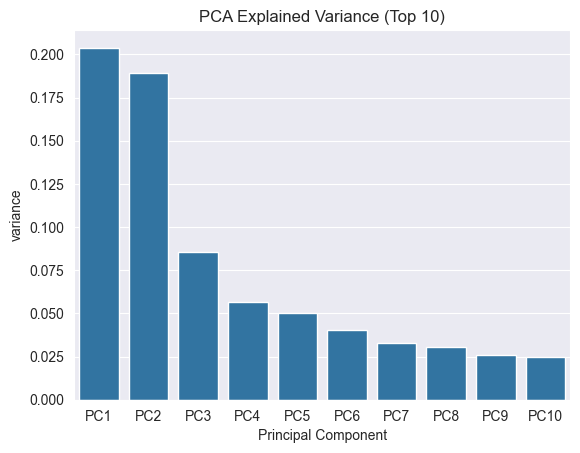

In [16]:
n_components_to_plot = 10
dataframe = pd.DataFrame({'variance': explained_variance[:n_components_to_plot],
                          'Principal Component': [f'PC{i+1}' for i in range(n_components_to_plot)]})
sns.barplot(x='Principal Component', y='variance', data=dataframe)
plt.title('PCA Explained Variance (Top 10)')
plt.show()

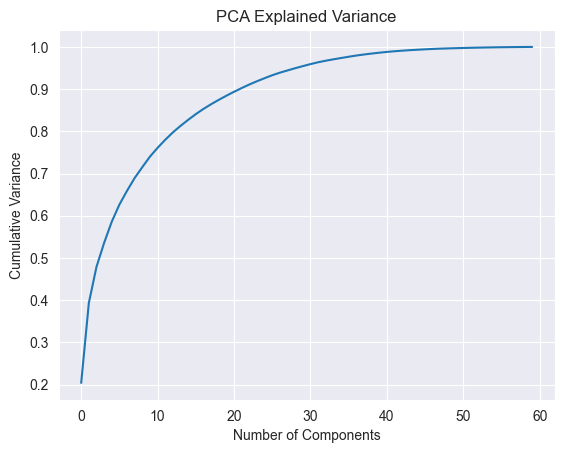

In [17]:
plt.plot(np.cumsum(explained_variance))
plt.title('PCA Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

In [18]:
# PCA with 2 components
pca_2 = PCA(n_components=2)
pca_2 = pca_2.fit(X_scaled)
pca_2d = pca_2.transform(X)

/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


In [19]:
# Encoding target variable if it's categorical (R/M for Sonar)
# We need to know the column name of Y.
target_col = Y.columns[0] if not Y.empty else df.columns[-1]
# Assuming standard Sonar dataset where 'R' is Rock and 'M' is Mine (Metal)
# We can map them to 0 and 1.
# Let's check unique values if possible, but since we can't run code, we assume standard.
# If it's not R/M, this might fail or need adjustment.
# We will use a generic label encoder or map if we knew the values.
# For now, let's try to map common values or just use as hue if seaborn handles it (it does).
# But for Logistic Regression later, we need numbers.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df[target_col])


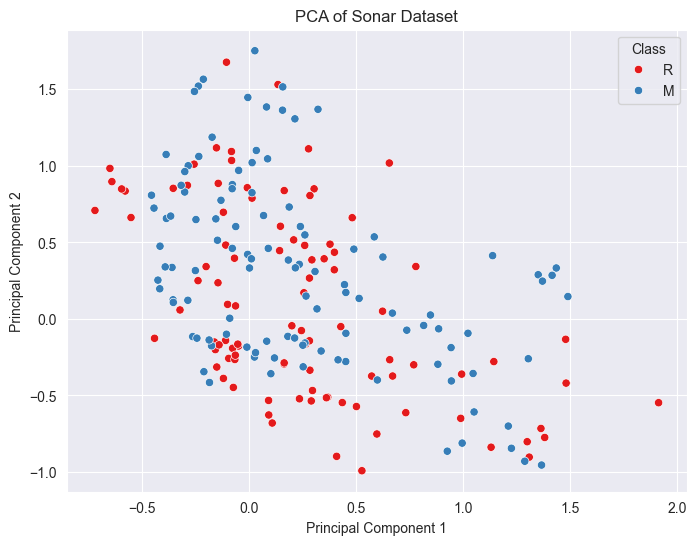

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=df[target_col], palette='Set1')
plt.title('PCA of Sonar Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class', loc='best')
plt.show()

In [21]:
# PCA with 4 components (following original notebook pattern)
pca_4 = PCA(n_components=4)
pca_4 = pca_4.fit(X_scaled)
pca_4d = pca_4.transform(X)

/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


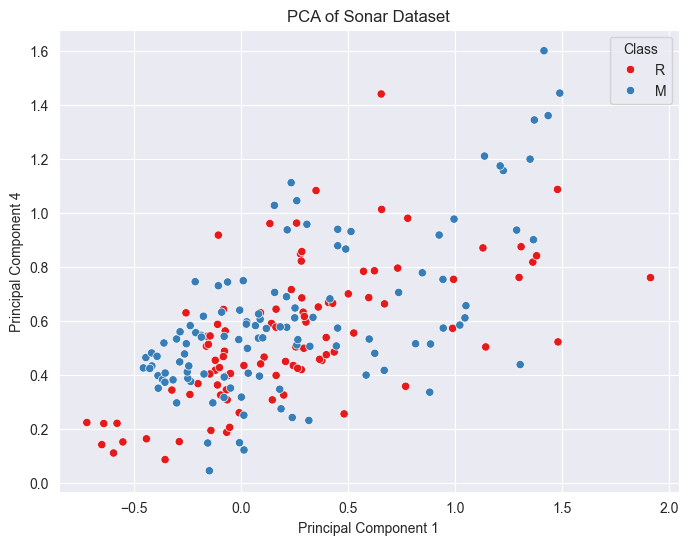

In [22]:
plt.figure(figsize=(8,6))
# Plotting 1st vs 4th component as in original notebook (pca_4d[:,3])
sns.scatterplot(x=pca_4d[:,0], y=pca_4d[:,3], hue=df[target_col], palette='Set1')
plt.title('PCA of Sonar Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 4') # Corrected label to match data
plt.legend(title='Class', loc='best')
plt.show()

## Supervised Learning Model
### 1. Training before applying PCA

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Using the scaled features X_scaled and encoded target
y = df['Target_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy before PCA:", accuracy_score(y_test, y_pred))

Accuracy before PCA: 0.7857142857142857


### 2. Training after applying PCA

In [24]:
# Using PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = model_pca.predict(X_test_pca)

print("Accuracy after PCA:", accuracy_score(y_test_pca, y_pred_pca))

Accuracy after PCA: 0.5952380952380952


## Inference
The accuracy of the model before applying PCA is calculated using all 60 features of the Sonar dataset.
After applying PCA and reducing the dimensions to 2 principal components, we observe the new accuracy.
Typically, reducing from 60 to 2 dimensions will result in some loss of information, potentially lowering accuracy.
However, if the first two components capture the majority of the variance, the drop might be acceptable for the gain in visualization and model simplicity.
Comparing the two accuracy scores allows us to evaluate the trade-off between dimensionality reduction and model performance for this specific dataset.